# Reflex Motion Tests

In this notebook the reflex motion feature is being tested. Everything regarding the new feature is still work in progress.

In [ ]:
from autocvd import autocvd
autocvd(num_gpus = 1)

import jax
import jax.numpy as jnp
from jax import random

# jax.config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt

from astropy import units as u

from odisseo import construct_initial_state
from odisseo.dynamics import DIRECT_ACC_MATRIX
from odisseo.option_classes import SimulationConfig, SimulationParams, PlummerParams
from odisseo.option_classes import NFW_POTENTIAL, DIFFRAX_BACKEND
from odisseo.initial_condition import Plummer_sphere
from odisseo.time_integration import time_integration
from odisseo.units import CodeUnits
from odisseo.visualization import energy_angular_momentum_plot


plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 15,
})
plt.style.use('default')

: 

## Setting up the simulation parameters and configurations

In [2]:
code_length = 10 * u.kpc
code_mass = 1e4 * u.Msun
G = 1
code_time = 1 * u.Gyr
code_units = CodeUnits(code_length, code_mass, G=1, unit_time = code_time )  


config = SimulationConfig(N_particles=100, 
                          return_snapshots = True, 
                          num_snapshots = 10, 
                          fixed_timestep=False,
                          num_timesteps=100,
                          softening = (0.1 * u.pc).to(code_units.code_length).value,
                          integrator=DIFFRAX_BACKEND,
                          acceleration_scheme=DIRECT_ACC_MATRIX,
                          external_accelerations=(NFW_POTENTIAL), 
                          reflex_motion = True)

params = SimulationParams(t_end = (4 * u.Gyr).to(code_units.code_time).value,
                          Plummer_params=PlummerParams(Mtot=(2.5e4 * u.Msun).to(code_units.code_mass).value,a=(8 * u.pc).to(code_units.code_length).value),  
                          G=code_units.G) 

key = random.PRNGKey(1)

#set up the particles in the initial state
positions, velocities, mass = Plummer_sphere(key=key, params=params, config=config)


W0219 16:29:47.822245  567900 subprocess_compilation.cc:241] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 6.1
W0219 16:29:47.822291  567900 subprocess_compilation.cc:244] Used ptxas at /export/home/rpretsch/Odisseo/.venv/lib/python3.12/site-packages/nvidia/cu13/bin/ptxas


JaxRuntimeError: UNIMPLEMENTED: /export/home/rpretsch/Odisseo/.venv/lib/python3.12/site-packages/nvidia/cu13/bin/ptxas ptxas too old. Falling back to the driver to compile.

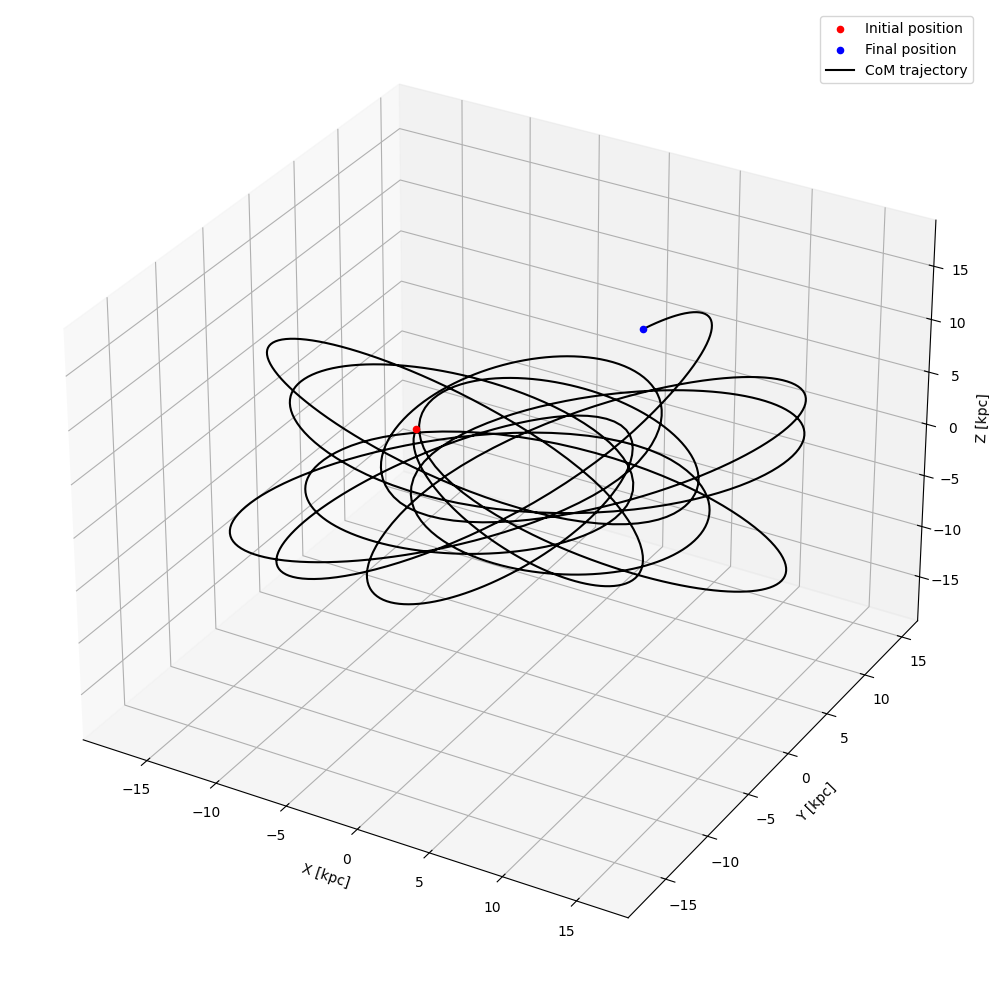

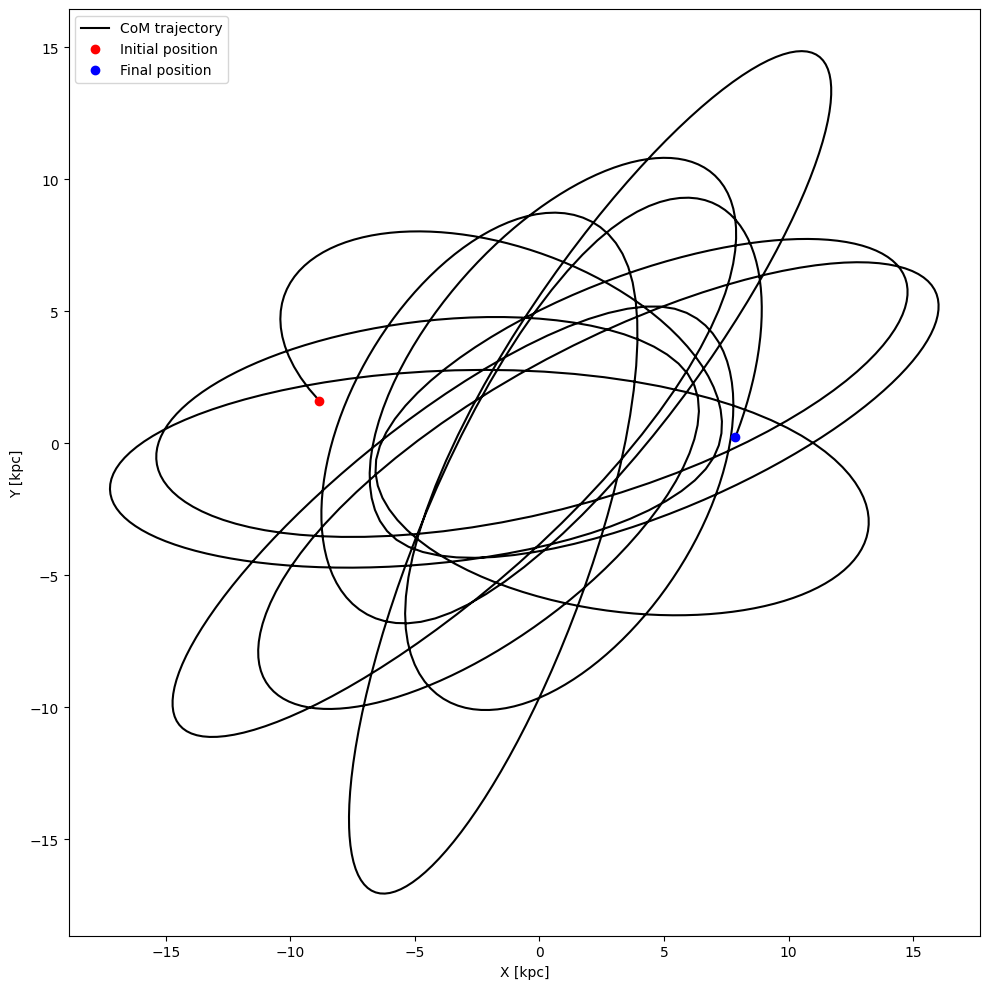

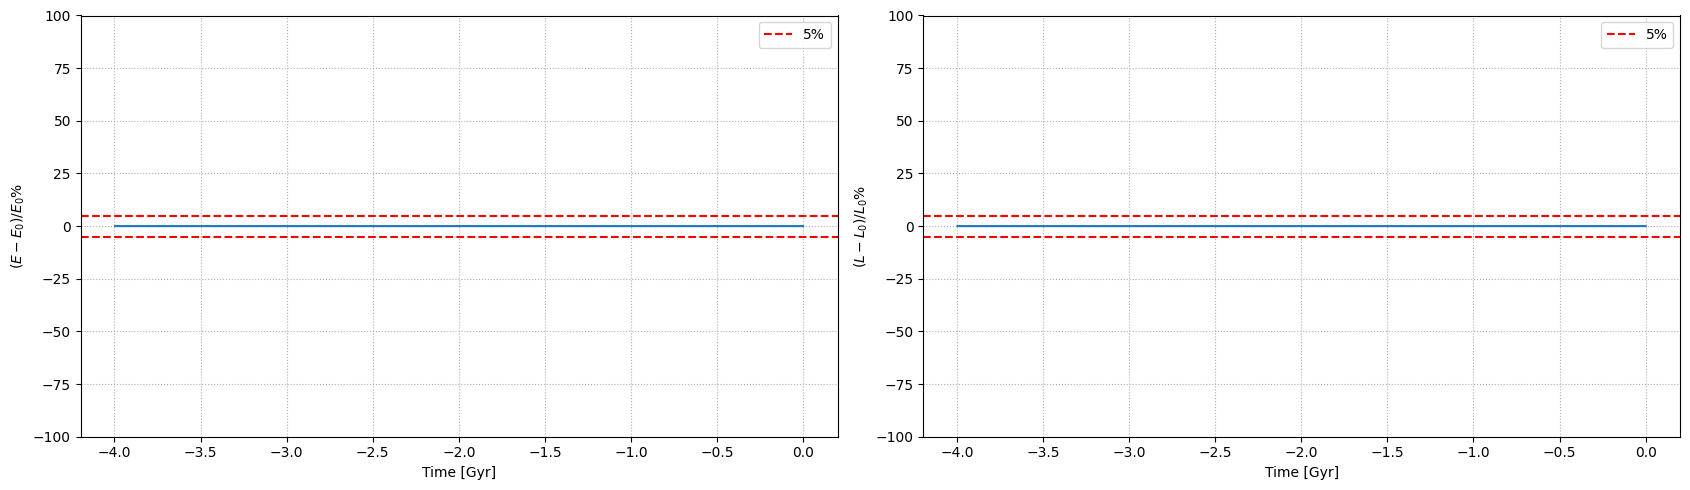

In [ ]:
#the center of mass needs to be integrated backwards in time first 
config_com = config._replace(N_particles=1,)
params_com = params._replace(t_end=-params.t_end,)



#this is the final position of the cluster, we need to integrate backwards in time 
pos_com_final = jnp.array([[7.86390455, 0.22748727, 16.41622487]]) * u.kpc.to(code_units.code_length)
vel_com_final = jnp.array([[-42.35458106, -103.69384675, -15.48729026]]) * (u.km/u.s).to(code_units.code_velocity)
mass_com = jnp.array([params_com.Plummer_params.Mtot])
final_state_com = construct_initial_state(pos_com_final, vel_com_final) # state is a (N_particles x 2 x 3)

# Add the Milky Way as particle in index 0
final_state_com = jnp.concatenate([jnp.zeros((1, 2, 3)), final_state_com], axis=0)
mass_com = jnp.concatenate([0, mass_com], axis=0) # Set its mass to zero, as its effect is included as an external potential

#evolution in time
snapshots_com = time_integration(final_state_com, mass_com, config_com, params_com)

#we can plot the snapshots of simulations, the snapshot are NameTuple with states=(N_snapshots x N_particles x 2 x 3) array
pos_com, vel_com = snapshots_com.states[-1, :, 0], snapshots_com.states[-1, :, 1]

##### CoM orbit plot####
fig = plt.figure(figsize=(15, 10), tight_layout=True)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(snapshots_com.states[-1, 0, 0, 0]* code_units.code_length.to(u.kpc), 
           snapshots_com.states[-1, 0, 0, 1]* code_units.code_length.to(u.kpc), 
           snapshots_com.states[-1,0, 0, 2]* code_units.code_length.to(u.kpc),c='r', label='Initial position')
ax.scatter(snapshots_com.states[0, 0, 0, 0]* code_units.code_length.to(u.kpc), 
           snapshots_com.states[0, 0, 0, 1]* code_units.code_length.to(u.kpc), 
           snapshots_com.states[0,0, 0, 2]* code_units.code_length.to(u.kpc), c='b', label='Final position')
ax.plot(snapshots_com.states[:, 0, 0, 0]* code_units.code_length.to(u.kpc), 
        snapshots_com.states[:, 0, 0, 1]* code_units.code_length.to(u.kpc), 
        snapshots_com.states[:,0, 0, 2]* code_units.code_length.to(u.kpc), 'k-', label='CoM trajectory')
ax.set_xlabel("X [kpc]")
ax.set_ylabel("Y [kpc]")
ax.set_zlabel("Z [kpc]")
ax.legend()
plt.show()

fig = plt.figure(figsize=(10, 10), tight_layout=True)
ax = fig.add_subplot(111)
ax.plot(snapshots_com.states[:, 0, 0, 0]* code_units.code_length.to(u.kpc), 
        snapshots_com.states[:, 0, 0, 1]* code_units.code_length.to(u.kpc), 'k-', label='CoM trajectory')
ax.plot(snapshots_com.states[-1, 0, 0, 0]* code_units.code_length.to(u.kpc), 
        snapshots_com.states[-1, 0, 0, 1]* code_units.code_length.to(u.kpc), 'ro', label='Initial position')
ax.plot(snapshots_com.states[0, 0, 0, 0]* code_units.code_length.to(u.kpc), 
        snapshots_com.states[0, 0, 0, 1]* code_units.code_length.to(u.kpc), 'bo', label='Final position')
ax.set_xlabel("X [kpc]")
ax.set_ylabel("Y [kpc]")
ax.legend()

#check conservation of energy and angular momentum
energy_angular_momentum_plot(snapshots_com, code_units,)